# ETL e Análise de Dados Cervejeiros

In [1]:
# bibliotecas
import requests
import json
import time
from datetime import datetime
from zoneinfo import ZoneInfo
import os
import matplotlib.pyplot as plt
import pandas as pd

# instalar o postgres e o python-dotenv para conectar com o banco de dados
!pip install psycopg2-binary
!pip install python-dotenv
import psycopg2
from dotenv import load_dotenv

# para evitar warnings quem poluem as saídas
import warnings
warnings.filterwarnings("ignore", message=".*SQLAlchemy.*")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 34.9 MB/s eta 0:00:00


Obtenção e preparação dos dados

In [ ]:
# Primeiramente, vamos obter dados do PunkAPI (https://publicapi.dev/punk-api)

  # Descrição oficial:
    # " PunkAPI is a FastAPI-based project that serves as a digital archive of BrewDog's DIY Dog beers.
    # It provides an API to access detailed information about each beer, including its recipe and associated image.
    # The catalog data was initially extracted from a PDF document and transformed into JSON and PNG files.
    # PunkAPI offers various endpoints to interact with this data. "

In [ ]:
'''
# Vamos começar obtendo os dados e salvando em um JSON
# não é necessário executar novamente esta célula, já que na célula seguinte
# foram disponibilizados os links para o download do arquivo aqui gerado (drive).
'''
# # caso, ainda assim, prefira executar esse código novamente, basta descomentá-lo

# ARQUIVO_SAIDA = "cervejas_raw.jsonl"  # um JSON por linha
# ARQUIVO_CHECKPOINT = "ultimo_id_salvo.txt" # para salvar o último ID obtido, caso necessário retomar
# ARQUIVO_ERROS = "erros_extracao.txt" # para salvar os IDs que falharam na requisição
# BASE_URL = "https://punkapi-alxiw.amvera.io/v3/beers/{}" # links para requisições
# TOTAL_CERVEJAS = 415 # São 415 cervejas (qualquer valor maior retorna isso: "Input should be less than or equal to 415")
# PAUSA_ENTRE_CHAMADAS = 1  # pausa em segundos, pra não sobrecarregar e evitar bloqueios

# # retoma de onde parou, se já tiver rodado antes
# inicio = 1
# if os.path.exists(ARQUIVO_CHECKPOINT):
#     with open(ARQUIVO_CHECKPOINT, "r") as f: # abre o ARQUIVO_CHECKPOINT
#         inicio = int(f.read().strip()) + 1 # O próximo ID será o que está no ARQUIVO_CHECKPOINT + 1

# with open(ARQUIVO_SAIDA, "a", encoding="utf-8") as saida: # modo append
#     for beer_id in range(inicio, TOTAL_CERVEJAS + 1): # acessar IDs do início ao final
#         try:
#             resposta = requests.get(BASE_URL.format(beer_id), timeout=10)
#             if resposta.status_code == 200:
#                 dado = resposta.json() # obtem a resposta como json
#                 saida.write(json.dumps(dado, ensure_ascii=False) + "\n") # escreve as informações no ARQUIVO_SAIDA
#                 print(f"✔ id {beer_id} salvo") # mostra os sucessos na saída desta célula

#                 # checkpoint a cada iteração de sucesso (caso seja preciso interromper e continuar depois)
#                 with open(ARQUIVO_CHECKPOINT, "w") as f:
#                     f.write(str(beer_id))
#             else:
#                 print(f"✘ id {beer_id} retornou status {resposta.status_code}") # mostra as falhas na saída desta célula
#                 # grava o ID da falha HTTP no arquivo de erros
#                 with open(ARQUIVO_ERROS, "a", encoding="utf-8") as erros:
#                     erros.write(f"ID {beer_id}: status {resposta.status_code}, \n")
#         except Exception as e:
#             print(f"✘ erro no id {beer_id}: {e}") # se der algum outro erro, cai nesse except
#             # grava o ID e a exceção gerada no arquivo de erros
#             with open(ARQUIVO_ERROS, "a", encoding="utf-8") as erros:
#                 erros.write(f"ID {beer_id}: erro de conexao/execucao - {e}\n")

#         time.sleep(PAUSA_ENTRE_CHAMADAS)

# print("Extração concluída.")

✔ id 1 salvo
✔ id 2 salvo
✔ id 3 salvo
✔ id 4 salvo
✔ id 5 salvo
✔ id 6 salvo
✔ id 7 salvo
✔ id 8 salvo
✔ id 9 salvo
✔ id 10 salvo
✔ id 11 salvo
✔ id 12 salvo
✔ id 13 salvo
✔ id 14 salvo
✔ id 15 salvo
✔ id 16 salvo
✔ id 17 salvo
✔ id 18 salvo
✔ id 19 salvo
✔ id 20 salvo
✔ id 21 salvo
✔ id 22 salvo
✔ id 23 salvo
✔ id 24 salvo
✔ id 25 salvo
✔ id 26 salvo
✔ id 27 salvo
✔ id 28 salvo
✔ id 29 salvo
✔ id 30 salvo
✔ id 31 salvo
✔ id 32 salvo
✔ id 33 salvo
✔ id 34 salvo
✔ id 35 salvo
✔ id 36 salvo
✔ id 37 salvo
✔ id 38 salvo
✔ id 39 salvo
✔ id 40 salvo
✔ id 41 salvo
✔ id 42 salvo
✔ id 43 salvo
✔ id 44 salvo
✔ id 45 salvo
✔ id 46 salvo
✔ id 47 salvo
✔ id 48 salvo
✔ id 49 salvo
✔ id 50 salvo
✔ id 51 salvo
✔ id 52 salvo
✔ id 53 salvo
✔ id 54 salvo
✔ id 55 salvo
✔ id 56 salvo
✔ id 57 salvo
✔ id 58 salvo
✔ id 59 salvo
✔ id 60 salvo
✔ id 61 salvo
✔ id 62 salvo
✔ id 63 salvo
✔ id 64 salvo
✔ id 65 salvo
✔ id 66 salvo
✔ id 67 salvo
✔ id 68 salvo
✔ id 69 salvo
✔ id 70 salvo
✔ id 71 salvo
✔ id 72 salvo
✔

In [2]:
# Nesta célula coloquei links para download direto dos arquivos gerados na célula anterior
# (pra não ter que executá-la toda vez)

# link pro cervejas_raw.jsonl no drive
# https://drive.google.com/file/d/19Z-4bfcAweu1TwRU87UDtgM2ybGVAjmS/view?usp=sharing

# link pro ultimo_id_salvo.txt no drive:
# https://drive.google.com/file/d/14Za4mD9uY0ddyF2VZnmgvqb7kxdp2VFB/view?usp=sharing


import gdown

# Pegar o ID do arquivo do link do Google Drive
file_cervejas_raw = '19Z-4bfcAweu1TwRU87UDtgM2ybGVAjmS'
file_ultimo_id_salvo = '14Za4mD9uY0ddyF2VZnmgvqb7kxdp2VFB'
#-------------------------------------------------------
# URL para fazer o download do cervejas_raw
url = f'https://drive.google.com/uc?id={file_cervejas_raw}'

# Baixando o arquivo
gdown.download(url, '_cervejas_raw_baixado.jsonl', quiet=False)
#-------------------------------------------------------

Downloading...
From: https://drive.google.com/uc?id=19Z-4bfcAweu1TwRU87UDtgM2ybGVAjmS
To: /content/_cervejas_raw_baixado.jsonl
100%|██████████| 841k/841k [00:00<00:00, 111MB/s]


'_cervejas_raw_baixado.jsonl'

In [17]:
# função flatten para limpar e simplificar os dados antes de salvá-los no banco de dados.

# dados como a temperatura de fervura ou o volume não vêm como um número puro (ex: 21).
# Eles vêm como um "dicionário" (um par de chaves e valores) que junta o número e a unidade de medida.
# Vamos tratá-los antes

import json
import os

def flatten_unidade(campo):
    """Função para achatar campos do tipo {'value': X, 'unit': 'celsius'} -> e retornar só o valor numérico."""
    if isinstance(campo, dict): # "Esse campo é um dicionário (dict)?"
                                #  Se o campo for {"value": 20, "unit": "litres"},
                                #  o isinstance diz: Sim (True), isso é um dicionário!
                                #  Se o campo for apenas o nome da cerveja "Punk IPA",
                                #  o isinstance diz: Não (False), isso é só um texto (string).

        return campo.get("value") # Então, se sim, pega apenas o que ta na chave "value"
                                  # (ou seja, um valor, como o número 20) e retorna

    return campo # Caso contrário (se for só um número ou texto comum), devolve ele do jeito que está

In [2]:
# conectar ao banco de dados

try: # primeiro, tenta buscar das chaves secretas nativas do Google Colab
    from google.colab import userdata
    DATABASE_URL = userdata.get('DATABASE_URL')
except ImportError: # Se não estiver no Colab (ex: VS Code local), busca do arquivo .env ou do sistema
    from dotenv import load_dotenv
    load_dotenv()
    DATABASE_URL = os.getenv("DATABASE_URL")

# verificar se a credencial foi encontrada por algum dos caminhos
if not DATABASE_URL:
    raise ValueError(
        "❌ Erro: A variável 'DATABASE_URL' não foi configurada.\n"
        "Se estiver no Google Colab, adicione-a no ícone de Chave (🔑 Secrets).\n"
        "Se estiver rodando localmente, crie um arquivo '.env' nesta pasta."
    )

# conectar com segurança
conn = psycopg2.connect(DATABASE_URL)
cur = conn.cursor()
print("✔ Conexão segura estabelecida com sucesso!")


#----------------------------------------------------------------------------------------------------
# vamos ter que fazer também uma função aqui pra garantir que a conexão esteja aberta quando precisar
# isso porque o Neon gratuito derruba conexões inativas automaticamente após alguns minutos sem uso
# então, pra evitar ficar repetindo o mesmo código pra toda hora mais pra frente, vamos fazer essa
# função pra fechar conexões que não funcionam e abrir outras que funcionam
def garantir_conexao():
    """
    Fecha conexões antigas penduradas para evitar estouro de limite no Neon
    e abre uma nova conexão limpa e estável para a célula atual.
    """
    global conn, cur

    # 1. Tenta fechar o cursor e a conexão anteriores, se existirem
    try:
        cur.close()
        conn.close()
    except:
        pass  # Se ainda não existirem ou já estiverem fechados, ignora

    # 2. Abre a nova conexão usando a URL oculta do ambiente
    try:
        from google.colab import userdata
        url = userdata.get('DATABASE_URL')
    except ImportError:
        import os
        url = os.getenv("DATABASE_URL")

    conn = psycopg2.connect(url)
    cur = conn.cursor()


#--------------------------------------------------------------------------------------------------
# para auditoria:
# aqui vamos ativar uma instrução pra salvar os comandos sql executados
# isso vai servir pra que, no final, seja possível fazer a auditoria
# de o que foi feito e quando
# Criamos uma função de apoio para executar e registrar os comandos ao mesmo tempo
log_queries = []

def executar_e_logar(cursor, sql_command):
    horario_brasilia_formatado = datetime.now(ZoneInfo("Brazil/East")).strftime('%d/%m/%Y %H:%M:%S')
    log_queries.append((sql_command.strip(), horario_brasilia_formatado))
    cursor.execute(sql_command)

print("✔ Log de comandos SQL ativado. A partir daqui, tudo que rodar nesta conexão ficará registrado.")

✔ Conexão segura estabelecida com sucesso!
✔ Log de comandos SQL ativado. A partir daqui, tudo que rodar nesta conexão ficará registrado.


In [26]:
# aqui vamos criar as tabelas (ou recriá-las, caso necessário)
''' Como os dados já foram inseridos anteriormente no banco,
    manteremos essa célula comentada para evitar perdê-los'''

# executar_e_logar(cur, """
# -- eliminar tabelas antigas, caso existam
# DROP TABLE IF EXISTS tab_harmonizacao;
# DROP TABLE IF EXISTS tab_lupulos;
# DROP TABLE IF EXISTS tab_maltes;
# DROP TABLE IF EXISTS tab_cervejas;

# -- criar tabela mestra
# CREATE TABLE tab_cervejas (
#     id INTEGER PRIMARY KEY,
#     nome TEXT,
#     tagline TEXT,
#     ano_criacao TEXT,
#     descricao TEXT,
#     abv REAL,
#     ibu REAL,
#     target_fg REAL,
#     target_og REAL,
#     ebc REAL,
#     srm REAL,
#     ph REAL,
#     attenuation_level REAL,
#     volume_litros REAL,
#     boil_volume_litros REAL,
#     mash_temp_celsius REAL,
#     fermentation_temp_celsius REAL,
#     levedura TEXT,
#     contribuido_por TEXT
# );

# -- criar tabela de maltes
# CREATE TABLE tab_maltes (
#     id SERIAL PRIMARY KEY,
#     cerveja_id INTEGER,
#     nome_malte TEXT,
#     quantidade_kg REAL,
#     FOREIGN KEY (cerveja_id) REFERENCES tab_cervejas(id)
# );

# -- criar tabela de lúpulos
# CREATE TABLE tab_lupulos (
#     id SERIAL PRIMARY KEY,
#     cerveja_id INTEGER,
#     nome_lupulo TEXT,
#     quantidade_g REAL,
#     estagio_adicao TEXT,
#     atributo TEXT,
#     FOREIGN KEY (cerveja_id) REFERENCES tab_cervejas(id)
# );

# -- criar tabela de harmonização
# CREATE TABLE tab_harmonizacao (
#     id SERIAL PRIMARY KEY,
#     cerveja_id INTEGER,
#     prato TEXT,
#     FOREIGN KEY (cerveja_id) REFERENCES tab_cervejas(id)
# );
# """)
# conn.commit()
# print("✔ Tabelas (tab_cervejas, tab_maltes, tab_lupulos, tab_harmonizacao) criadas.")

✔ Conexão segura estabelecida com sucesso!
✔ Log de comandos SQL ativado. A partir daqui, tudo que rodar nesta conexão ficará registrado.
✔ Tabelas (tab_cervejas, tab_maltes, tab_lupulos, tab_harmonizacao) criadas.


In [27]:
# aqui vamos ler o jsonl das cervejas e transformar os dados para criar tabelas
''' Também manteremos esta célula comentada, pois os dados que possuímos já foram
    inseridos no banco e não há novos dados para inserir neste momento'''


# # contadores começarão em 0 (queremos mostrar quantos itens cada tabela terá ao final)
# total_cervejas = 0
# total_maltes = 0
# total_lupulos = 0
# total_harmonizacoes = 0

# garantir_conexao() # conectar de novo pra evitar problemas de queda inesperada

# # limpar as tabelas antes de começar
# cur.execute("TRUNCATE tab_harmonizacao, tab_lupulos, tab_maltes, tab_cervejas CASCADE;")
# # o comando TRUNCATE apaga todos os registros de uma tabela
# # e o CASCADE força o Postgres a quebrar qualquer trava de integridade referencial.
#   # por exemplo, se tentassemos rodar apenas TRUNCATE tab_cervejas;
#   # o banco retornaria um erro bloqueando a operação, dizendo que tab_maltes faz referência a ela.
#   # então o CASCADE diz ao banco:
#   # "Pode limpar a tabela principal e, se houver qualquer dependência ou vínculo
#   # em outras tabelas que eu esqueci de listar, apague em cascata também"
# conn.commit()

# # Primeiro, lemos todo o arquivo JSONL para a memória para podermos fatiar em lotes
# cervejas_reais = []
# ARQUIVO_ENTRADA = "_cervejas_raw_baixado.jsonl" # os dados estão nesse arquivo
# with open(ARQUIVO_ENTRADA, "r", encoding="utf-8") as f:
#     for linha in f:
#         linha = linha.strip()
#         if linha:
#             cervejas_reais.append(json.loads(linha))

# # --- INSERÇÃO EM LOTES COM DETECÇÃO DE FALHAS ---
# TAMANHO_LOTE = 75
# cur.execute("BEGIN;")  # marca o início de toda a operação

# for i in range(0, len(cervejas_reais), TAMANHO_LOTE): # repete len(cervejas_reais) vezes e o passo é TAMANHO_LOTE
#     lote = cervejas_reais[i:i + TAMANHO_LOTE] # fatia a lista em TAMANHO_LOTE elementos
#     nome_savepoint = f"lote_reais_{i}" # especificando o checkpoint

#     print(f"\n--- Tratando lote {i//TAMANHO_LOTE + 1}: ids [{lote[0].get('id')} a {lote[-1].get('id')}] ---") # informa 1º e último ID do lote
#     # print(f"\n--- Tratando lote {i//TAMANHO_LOTE + 1}: ids {[c.get('id') for c in lote]} ---") # caso queira informar TODOS os IDs do lote
#     cur.execute(f"SAVEPOINT {nome_savepoint};") # checkpoint

#     try:
#         for cerveja in lote: # para cada cerveja do lote:

#             # --- EXTRAÇÃO E LIMPEZA DE DADOS (usando a função flatten_unidade que criamos antes) ---

#             # Primeiro, busca o dicionário de método de fabricação
#             method = cerveja.get("method") or {} # Se não existir, assume um dicionário vazio {} para não quebrar o código
#             mash_temp_list = method.get("mash_temp") or [] # Busca a lista de temperaturas de mostura (mash_temp).
#                                                     # Se não achar, assume uma lista vazia []
#             mash_temp_c = flatten_unidade(mash_temp_list[0]["temp"]) if mash_temp_list else None
#             # Se a lista de mostura tiver dados, pega o primeiro item, acessa a chave ["temp"] (que é um dicionário)
#             # e passa pelo flatten_unidade para extrair só o número da temperatura.
#                                                                     # Se a lista for vazia, define como None.
#             fermentation = method.get("fermentation") or {} # # Busca o dicionário de fermentação.
#                                                       # Se não achar, assume {}
#             fermentation_temp_c = flatten_unidade(fermentation.get("temp")) # Acessa a chave "temp" da fermentação
#                                                           # e extrai apenas o número puro (sem a unidade 'celsius')

#             volume = flatten_unidade(cerveja.get("volume"))  # Extrai apenas o número puro do volume total da cerveja
#                                                             # (ex: transforma {"value": 20, "unit": "liters"} em 20)
#             boil_volume = flatten_unidade(cerveja.get("boil_volume")) # Extrai apenas o número puro do volume de fervura
#                                                                       # (boil_volume)

#             ingredientes = cerveja.get("ingredients") or {} # Busca o dicionário de ingredientes.
#                                                     # Se não achar, assume um dicionário vazio {}


#             # -- INSERÇÃO DOS DADOS NAS TABELAS --

#             # 1. tabela principal (Insere ou atualiza os dados gerais da cerveja)
#             cur.execute("""
#                 INSERT INTO tab_cervejas
#                 (id, nome, tagline, ano_criacao, descricao, abv, ibu, target_fg, target_og,
#                  ebc, srm, ph, attenuation_level, volume_litros, boil_volume_litros,
#                  mash_temp_celsius, fermentation_temp_celsius, levedura, contribuido_por)
#                 VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
#             """, (
#                 cerveja.get("id"), cerveja.get("name"), cerveja.get("tagline"),
#                 cerveja.get("first_brewed"), cerveja.get("description"),
#                 cerveja.get("abv"), cerveja.get("ibu"), cerveja.get("target_fg"), cerveja.get("target_og"),
#                 cerveja.get("ebc"), cerveja.get("srm"), cerveja.get("ph"), cerveja.get("attenuation_level"),
#                 volume, boil_volume, mash_temp_c, fermentation_temp_c,
#                 ingredientes.get("yeast"), cerveja.get("contributed_by"),
#             ))
#             total_cervejas += 1 # soma 1 no contador de cervejas salvas

#             # 2. maltes (relação do tipo "um pra muitos")
#             # Como uma cerveja leva vários maltes, roda um loop para cada um deles
#             for malte in ingredientes.get("malt") or []:
#                 cur.execute("""
#                     INSERT INTO tab_maltes (cerveja_id, nome_malte, quantidade_kg)
#                     VALUES (%s,%s,%s)
#                 """, (
#                     cerveja.get("id"),  # vincula o malte ao ID da cerveja atual
#                     malte.get("name"), # pega o nome do malte (ex: "Maris Otter Extra Pale")
#                     flatten_unidade(malte.get("amount")) # extrai apenas o número do peso em kg
#                 ))
#                 total_maltes += 1 # soma 1 no contador de maltes salvos

#             # 3. lúpulos (relação do tipo "um pra muitos")
#             for lupulo in ingredientes.get("hops") or []:
#                 cur.execute("""
#                     INSERT INTO tab_lupulos (cerveja_id, nome_lupulo, quantidade_g, estagio_adicao, atributo)
#                     VALUES (%s,%s,%s,%s,%s)
#                 """, (
#                     cerveja.get("id"), # vincula o lúpulo ao ID da cerveja atual
#                     lupulo.get("name"), # pega o nome do lúpulo (ex: "Fuggles")
#                     flatten_unidade(lupulo.get("amount")), # extrai apenas o número do peso em gramas (g)
#                     lupulo.get("add"), # momento em que o lúpulo é adicionado (ex: "start", "middle")
#                     lupulo.get("attribute"), # o objetivo do lúpulo (ex: "bitter" para amargor, "flavour" para sabor)
#                 ))
#                 total_lupulos += 1 # soma 1 no contador de lúpulos salvos

#             # 4. harmonização com comida (relação do tipo "um pra muitos")
#             # Loop para salvar as sugestões de pratos
#             for prato in cerveja.get("food_pairing") or []:
#                 cur.execute("INSERT INTO tab_harmonizacao (cerveja_id, prato) VALUES (%s,%s)",
#                             (cerveja.get("id"), prato)) # vincula o texto do prato ao ID da cerveja
#                 total_harmonizacoes += 1 # soma 1 no contador de harmonizações

#         cur.execute(f"RELEASE SAVEPOINT {nome_savepoint};")  # se o lote inteiro deu certo, consolida
#         print(f"✔ Lote inserido com sucesso ({len(lote)} linhas).")

#     except Exception as e: # se tiver algum erro:
#         # No Postgres, o ROLLBACK TO limpa o erro da transação e deve ser executado imediatamente
#         cur.execute(f"ROLLBACK TO {nome_savepoint};") # volta o estado do banco ao checkpoint
#         print(f"✘ Lote revertido por erro: {e}")
#         print("  (mesmo as linhas válidas deste lote foram perdidas, porque o rollback é por lote inteiro)")

#         # Como as queries foram revertidas, removemos as contagens que haviam sido somadas neste lote
#         for cerveja in lote:
#             total_cervejas -= 1
#             total_maltes -= len((cerveja.get("ingredients") or {}).get("malt") or [])
#             total_lupulos -= len((cerveja.get("ingredients") or {}).get("hops") or [])
#             total_harmonizacoes -= len(cerveja.get("food_pairing") or [])

#         # Registro de falhas: aqui vamos registrar as cervejas dos lotes que falharem
#         # Vamos escrever num txt, pois salvar em memória (numa lista, por exemplo) é arriscado
#         with open("lotes_reprovados_insercao_inicial.txt", "a", encoding="utf-8") as f:
#             for cerveja in lote:
#                 # Transforma o dicionário da cerveja em uma linha de texto JSON para salvar
#                 f.write(json.dumps(cerveja) + "\n")
#         print("💾 Dados do lote salvos em 'lotes_reprovados_insercao_inicial.txt' para recuperação posterior.")

# conn.commit()  # consolida definitivamente tudo que não foi revertido
# print("-----------------------------------------------------------------------------------")
# print("\nOperação de inserção finalizada.")

# # Imprimir o resumo final consolidado na tela com o total de registros processados
# print(f"Carregadas {total_cervejas} cervejas, {total_maltes} maltes, "
#       f"{total_lupulos} lúpulos, {total_harmonizacoes} harmonizações.")



--- Tratando lote 1: ids [1 a 75] ---
✔ Lote inserido com sucesso (75 linhas).

--- Tratando lote 2: ids [76 a 150] ---
✔ Lote inserido com sucesso (75 linhas).

--- Tratando lote 3: ids [151 a 225] ---
✔ Lote inserido com sucesso (75 linhas).

--- Tratando lote 4: ids [226 a 300] ---
✔ Lote inserido com sucesso (75 linhas).

--- Tratando lote 5: ids [301 a 375] ---
✔ Lote inserido com sucesso (75 linhas).

--- Tratando lote 6: ids [376 a 415] ---
✔ Lote inserido com sucesso (40 linhas).
-----------------------------------------------------------------------------------

Operação de inserção finalizada.
Carregadas 415 cervejas, 1627 maltes, 2255 lúpulos, 1234 harmonizações.


In [23]:
# Aqui vamos conferir as tabelas, mostrando algumas linhas de cada

garantir_conexao() # conectar de novo pra evitar problemas de queda inesperada

print("------------------------Tabela de cervejas------------------------")
# print(pd.read_sql_query("SELECT * FROM tab_cervejas LIMIT 5;", conn))
display(pd.read_sql_query("SELECT * FROM tab_cervejas ORDER BY id LIMIT 3;", conn))

print("\n\n\n------------------------Tabela de maltes------------------------")
# print(pd.read_sql_query("SELECT * FROM tab_maltes LIMIT 5;", conn))
display(pd.read_sql_query("SELECT * FROM tab_maltes LIMIT 3;", conn))

print("\n\n\n------------------------Tabela de lúpulos------------------------")
# print(pd.read_sql_query("SELECT * FROM tab_lupulos LIMIT 5;", conn))
display(pd.read_sql_query("SELECT * FROM tab_lupulos LIMIT 3;", conn))

print("\n\n\n------------------------Tabela de harmonização------------------------")
# print(pd.read_sql_query("SELECT * FROM tab_harmonizacao LIMIT 5;", conn))
display(pd.read_sql_query("SELECT * FROM tab_harmonizacao LIMIT 3;", conn))


------------------------Tabela de cervejas------------------------


,id,nome,tagline,ano_criacao,descricao,abv,ibu,target_fg,target_og,ebc,srm,ph,attenuation_level,volume_litros,boil_volume_litros,mash_temp_celsius,fermentation_temp_celsius,levedura,contribuido_por
0,1,Punk IPA 2007 - 2010,Post Modern Classic. Spiky. Tropical. Hoppy.,04/2007,Our flagship beer that kick started the craft ...,6.0,60.0,1010.0,1056.0,17.0,8.5,4.4,82.14,20.0,25.0,65.0,19.0,Wyeast 1056 - American Ale™,Sam Mason <samjbmason>
1,2,Punk IPA 2010 - Current,Post Modern Classic. Spiky. Tropical. Hoppy.,10/2010,Punk IPA. Amplified. In 2010 we finally got ou...,5.6,40.0,1011.0,1055.0,15.0,7.6,4.4,78.00,20.0,25.0,66.0,19.0,Wyeast 1056 - American Ale™,Sam Mason <samjbmason>
2,3,The Physics,Laid Back Amber Beer.,04/2007,A hoppy Amber Ale that won World's Best Amber ...,5.0,47.0,1010.0,1048.5,65.0,32.5,4.4,79.40,20.0,25.0,65.0,19.0,Wyeast 1056 - American Ale™,Sam Mason <samjbmason>





------------------------Tabela de maltes------------------------


,id,cerveja_id,nome_malte,quantidade_kg
0,1,1,Extra Pale,5.30
1,2,2,Extra Pale,4.38
2,3,2,Caramalt,0.25





------------------------Tabela de lúpulos------------------------


,id,cerveja_id,nome_lupulo,quantidade_g,estagio_adicao,atributo
0,1,1,Ahtanum,17.5,start,bitter
1,2,1,Chinook,15.0,start,bitter
2,3,1,Crystal,17.5,middle,flavour





------------------------Tabela de harmonização------------------------


,id,cerveja_id,prato
0,1,1,Spicy carne asada with a pico de gallo sauce
1,2,1,Shredded chicken tacos with a mango chilli lim...
2,3,1,Cheesecake with a passion fruit swirl sauce


Queries

In [52]:
# vamos começar a fazer algumas queries pra explorar o banco

# 1. Lúpulos mais usados em todo o catálogo
q1 = """
SELECT nome_lupulo, COUNT(*) as vezes_usado
FROM tab_lupulos
GROUP BY nome_lupulo
ORDER BY vezes_usado DESC
LIMIT 10;
"""
garantir_conexao()
print("--- Lúpulos mais usados ---")
display(pd.read_sql_query(q1, conn))

--- Lúpulos mais usados ---


,nome_lupulo,vezes_usado
0,Simcoe,229
1,Centennial,196
2,Amarillo,188
3,Citra,177
4,Chinook,172
5,Cascade,125
6,Columbus,117
7,Mosaic,87
8,Magnum,70
9,Nelson Sauvin,55


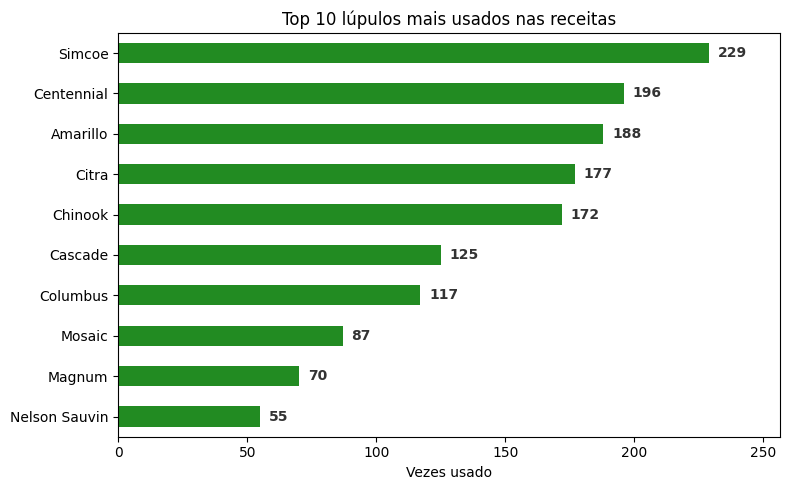

In [25]:
# 1b) lúpulos mais usados no catálogo

q = """
SELECT nome_lupulo, COUNT(*) as vezes_usado
FROM tab_lupulos
GROUP BY nome_lupulo
ORDER BY vezes_usado DESC
LIMIT 10;
"""
garantir_conexao()
df_lupulos = pd.read_sql_query(q, conn)

# Criando o gráfico com a cor forestgreen
ax = df_lupulos.plot(kind='barh', x='nome_lupulo', y='vezes_usado', legend=False, figsize=(8,5), color='forestgreen')

# Adicionando o rótulo de contagem ao lado de cada barra
for bar in ax.patches:
    width = bar.get_width()
    if width > 0:
        label = f"{int(width)}"

        ax.text(
            width + (df_lupulos['vezes_usado'].max() * 0.015),
            bar.get_y() + bar.get_height() / 2,
            label,
            ha='left',
            va='center',
            fontsize=10,
            fontweight='bold',
            color='#333333'
        )

# Mantém a folga no limite do eixo X para o texto não cortar
ax.set_xlim(0, df_lupulos['vezes_usado'].max() * 1.12)

plt.title("Top 10 lúpulos mais usados nas receitas")
plt.xlabel("Vezes usado")
plt.ylabel("")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("grafico_lupulos.png", dpi=150)
plt.show()

In [51]:
# 2. Ranking das cervejas mais amargas por litro de álcool (IBU/ABV) - "custo-benefício" de amargor

q = """
SELECT
    nome,
    abv,
    ibu,
    ROUND((ibu * 1.0 / NULLIF(abv, 0))::numeric, 2) as ibu_por_abv
FROM tab_cervejas
WHERE ibu IS NOT NULL AND abv IS NOT NULL AND abv > 0
ORDER BY ibu_por_abv DESC
LIMIT 10;
"""

garantir_conexao()
print("--- Maior IBU por grau de ABV ---")
display(pd.read_sql_query(q, conn))

--- Maior IBU por grau de ABV ---


,nome,abv,ibu,ibu_por_abv
0,Nanny State,0.5,55.0,110.00
1,How To Disappear Completely,3.5,198.0,56.57
2,Tactical Nuclear Penguin,32.0,1157.0,36.16
3,Hop Shot,7.0,250.0,35.71
4,Black Hammer,7.2,250.0,34.72
5,Rye Hammer,7.2,250.0,34.72
6,Monk Hammer,7.2,250.0,34.72
7,Jack Hammer,7.2,250.0,34.72
8,Chili Hammer,7.2,250.0,34.72
9,Sink The Bismarck!,41.0,1085.0,26.46


In [27]:
# Mas veja como tem valores de IBU bem estranhos aí...

o IBU é um valor que pode ser objetivamente calculado, podendo ser maior que 120.

porém, a habilidade humana de perceber a diferença em valores acima dessa marca é praticamente nula
            
    Uma referência para conferência: https://beerconnoisseur.com/articles/whats-meaning-ibu/

então, podemos considerar um limite prático de 120 para evitar que valores exorbitantes deturpem estatísticas como a média, por exemplo.

In [28]:
# 3. considerando isso, vamos criar uma nova coluna para registrar o IBU com esse limite prático de 120

garantir_conexao()
cur.execute("ALTER TABLE tab_cervejas ADD COLUMN ibu_percebido REAL;")
cur.execute("UPDATE tab_cervejas SET ibu_percebido = LEAST(ibu, 120) WHERE ibu IS NOT NULL;")
conn.commit()

#conferir:
pd.read_sql_query("SELECT id, nome, ibu, ibu_percebido FROM tab_cervejas WHERE ibu >= 120", conn)

,id,nome,ibu,ibu_percebido
0,20,Zephyr,125.0,120.0
1,25,How To Disappear Completely,198.0,120.0
2,33,Tactical Nuclear Penguin,1157.0,120.0
3,37,Hardcore IPA,125.0,120.0
4,38,Sink The Bismarck!,1085.0,120.0
5,43,Prototype 27,149.0,120.0
6,46,Hardkogt IPA,175.0,120.0
7,61,AB:06,150.0,120.0
8,90,Jack Hammer,250.0,120.0
9,185,Sorachi Bitter - B-Sides,130.0,120.0


# Vamos inspecionar outra coluna: a de temperaturas de fermentação.


Como a maioria das leveduras de cerveja não sobrevive acima de ~35-40°C, podemos considerar que dados muito distantes desse valor são erros.

Com relação ao limite inferior, podemos considerar que, abaixo de 4°C, a atividade metabólica da levedura de cerveja cai para praticamente zero. Temperaturas menores que essa provavelmente não representam a temperatura de fermentação, e sim temperatura de maturação/lagering ou simplesmente um erro de preenchimento.

In [39]:
# 4. Então, vamos isolar os registros suspeitos
#
q = """
SELECT id, nome, fermentation_temp_celsius, levedura
FROM tab_cervejas WHERE fermentation_temp_celsius > 40 OR fermentation_temp_celsius < 4;"""
garantir_conexao()
pd.read_sql_query(q, conn)

,id,nome,fermentation_temp_celsius,levedura
0,76,Simcoe,99.0,Wyeast 1056 - American Ale™


In [ ]:
# obs.: a levedura Wyeast 1056 - American Ale™ é da família Ale (Saccharomyces cerevisiae).
# As Ales gostam de climas amenos (geralmente entre 15°C e 22°C).

In [40]:
# 5. agora vamos investigar se os registros suspeitos não vêm de erros de unidades de temperatura..
# Um erro comum de import é confundir Celsius com Fahrenheit.
# Vamos tentar converter os valores suspeitos de Fahrenheit pra Celsius
# pra ver se eles caem numa faixa plausível de fermentação (10-30°C)

q = """SELECT id, nome, fermentation_temp_celsius as valor_original,
       ROUND(((fermentation_temp_celsius - 32) * 5.0/9)::numeric, 1) AS se_fosse_fahrenheit
FROM tab_cervejas
WHERE fermentation_temp_celsius > 40 OR fermentation_temp_celsius < 4;"""
garantir_conexao()
pd.read_sql_query(q, conn)

,id,nome,valor_original,se_fosse_fahrenheit
0,76,Simcoe,99.0,37.2


In [38]:
# ''' !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!'''
'''# célula para voltar os IBUS e a temperatura de fermentação ao normal'''
# ''' !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!'''
"""!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!"""

# # Garante a conexão ativa com o Neon
# garantir_conexao()

# # Deleta a coluna para remover o spoiler
# # cur.execute("ALTER TABLE tab_cervejas DROP COLUMN IF EXISTS ibu_percebido;")
# cur.execute("UPDATE tab_cervejas SET fermentation_temp_celsius = 99 WHERE id = 76;")
# conn.commit()

# print("✔ Feito")


✔ Feito


In [41]:
# 6.
# 37 °C é uma temperatura extremamente alta pra uma levedura Ale, então esse registro está definitivamente errado.
# Então vamos corrigir esse valor manualmente:
garantir_conexao()
cur.execute("UPDATE tab_cervejas SET fermentation_temp_celsius = NULL WHERE id = 76;")
conn.commit()
print("Correção aplicada.")
# registro id 76 (Simcoe) tinha temperatura de fermentação de 99°C,
# fisicamente inviável para sobrevivência de levedura (a maioria não tolera acima de ~40°C);
# nenhuma hipótese de erro de conversão de unidade explicou o valor, então foi definido como desconhecido."

# verificar:
pd.read_sql_query("SELECT id, nome, fermentation_temp_celsius FROM tab_cervejas WHERE id = 76", conn)

Correção aplicada.


,id,nome,fermentation_temp_celsius
0,76,Simcoe,None


In [ ]:
# Obs.: As funções de agregação (AVG, SUM, MIN, MAX) ignoram os valores NULL automaticamente.
# Porém, em etapa posteriores de preparação para Machine Learning,
# esses valores deverão ser tratados antes de treinar o modelo.

In [50]:
# 7. Agora vamos testar correlações
# Será que cervejas mais fortes tendem a ser mais amargas?
# Para responder isso, vamos fazer uma correlação simples entre ABV (teor alcóolico) e IBU (amargor)
# (vamos utilizar a coluna de ibu percebido que criamos)

q = """
SELECT
    CASE
        WHEN abv < 5 THEN 'baixo (<5%)'
        WHEN abv < 8 THEN 'médio (5-8%)'
        ELSE 'alto (8%+)'
    END as faixa_abv,
    ROUND((AVG(ibu_percebido))::numeric, 1) as ibu_percebido_medio,
    COUNT(*) as qtd_cervejas
FROM tab_cervejas
WHERE abv IS NOT NULL AND ibu_percebido IS NOT NULL
GROUP BY faixa_abv
ORDER BY ibu_percebido_medio DESC;
"""
garantir_conexao()
print("---------- IBU (percebido) médio por faixa de ABV ----------")
display(pd.read_sql_query(q, conn))

---------- IBU (percebido) médio por faixa de ABV ----------


,faixa_abv,ibu_percebido_medio,qtd_cervejas
0,alto (8%+),66.5,142
1,médio (5-8%),48.9,189
2,baixo (<5%),30.9,79


Explicação: Cervejas com ABV mais alto possuem uma quantidade muito maior de açúcar residual de malte que não foi totalmente transformado em álcool pelas leveduras. Para que a cerveja não fique excessivamente doce e enjoativa, os cervejeiros aumentam a carga de lúpulo (gerando um IBU mais alto), trazendo equilíbrio ao paladar.

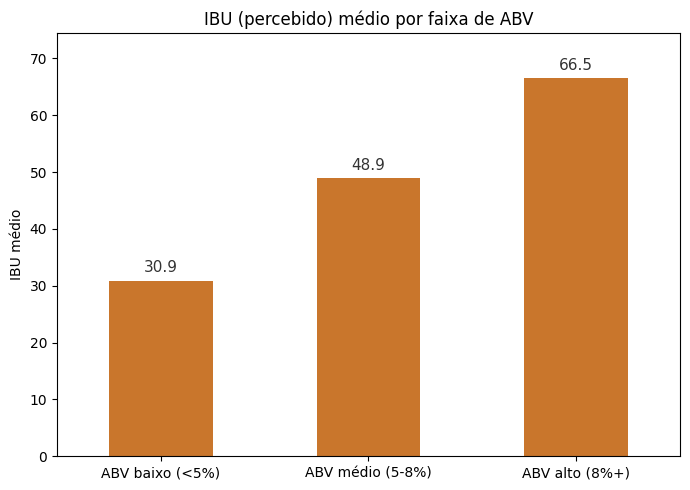

In [47]:
# 7b) IBU médio por faixa de ABV (usa ibu_percebido, já tratado)

q = """
SELECT
    CASE
        WHEN abv < 5 THEN 'ABV baixo (<5%)'
        WHEN abv < 8 THEN 'ABV médio (5-8%)'
        ELSE 'ABV alto (8%+)'
    END as faixa_abv,
    ROUND((AVG(ibu_percebido))::numeric, 1) as ibu_medio
FROM tab_cervejas
WHERE abv IS NOT NULL AND ibu_percebido IS NOT NULL
GROUP BY faixa_abv
ORDER BY ibu_medio;
"""
garantir_conexao()
df_ibu = pd.read_sql_query(q, conn)

# Criando o gráfico
ax = df_ibu.plot(kind='bar', x='faixa_abv', y='ibu_medio', legend=False, figsize=(7,5), color='#c9762c')

# Adicionando apenas o valor do IBU médio em cima de cada barra
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        # Formata o rótulo apenas com uma casa decimal (ex: 35.4)
        label = f"{height:.1f}"

        # Insere o texto centralizado logo acima do topo da barra
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + (df_ibu['ibu_medio'].max() * 0.015), # Pequena folga vertical proporcional
            label,
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='normal',
            color='#333333' # Tom de cinza escuro para melhor legibilidade
        )

# Garante espaço no topo para o rótulo não ser cortado pela borda do gráfico
ax.set_ylim(0, df_ibu['ibu_medio'].max() * 1.12)

plt.title("IBU (percebido) médio por faixa de ABV")
plt.xlabel("")
plt.ylabel("IBU médio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("grafico_ibu_por_abv.png", dpi=150)
plt.show()

In [49]:
# 8. Agora vamos analisar quais receitas usam mais ingredientes (receitas complexas)
# para isso, podemos considerar a quantidade de malte e lúpulo utilizados na receita

q = """
SELECT
    c.nome,
    tagline,
    COALESCE(sub_tab_lupulo.qtd_lupulo, 0) AS qtd_lupulo,
                                                    -- A função COALESCE serve para garantir que,
                                                    -- se uma cerveja não tiver nenhum malte ou lúpulo cadastrado
                                                    -- (retornando NULL), o SQL transforme esse NULL em 0
    COALESCE(sub_tab_malte.qtd_malte, 0) AS qtd_malte,
    (COALESCE(sub_tab_lupulo.qtd_lupulo, 0) + COALESCE(sub_tab_malte.qtd_malte, 0)) AS qtd_ingredientes
FROM tab_cervejas c

-- Subquery para contar lúpulos de forma isolada
LEFT JOIN (
    SELECT cerveja_id, COUNT(*) AS qtd_lupulo
    FROM tab_lupulos
    GROUP BY cerveja_id
) AS sub_tab_lupulo ON c.id = sub_tab_lupulo.cerveja_id

-- Subquery para contar maltes de forma isolada
LEFT JOIN (
    SELECT cerveja_id, COUNT(*) AS qtd_malte
    FROM tab_maltes
    GROUP BY cerveja_id
) AS sub_tab_malte ON c.id = sub_tab_malte.cerveja_id

ORDER BY qtd_ingredientes DESC
LIMIT 10;
"""
garantir_conexao()
print("------------------------------------ Receitas mais complexas (mais ingredientes) ------------------------------------")
display(pd.read_sql_query(q, conn))


------------------------------------ Receitas mais complexas (mais ingredientes) ------------------------------------


,nome,tagline,qtd_lupulo,qtd_malte,qtd_ingredientes
0,Nanny State,Alcohol Free Hoppy Ale.,15,8,23
1,Clockwork Tangerine,Citrus IPA.,18,3,21
2,Transatlantic Telegram,New England West Coast IPA.,13,5,18
3,How To Disappear Completely,Fake Fix Double IPA.,10,8,18
4,Sorachi Bitter - B-Sides,Sorachi Ace Bitter.,12,5,17
5,AB:06,Imperial Black IPA.,11,5,16
6,#Mashtag 2015,US Hopped Black Barley Wine.,10,6,16
7,5am Saint,Bittersweet Chaos. Malty. Fruity. Bite.,11,5,16
8,Black Dog,Hoppy Black Wheat Stout.,10,6,16
9,Misspent Youth,Milk & Honey Scotch Ale.,6,10,16


In [53]:
# 9. Agora vamos ver os pratos de harmonização mais recomendados no catálogo
q = """
SELECT prato, COUNT(*) as vezes_recomendado
FROM tab_harmonizacao
GROUP BY prato
ORDER BY vezes_recomendado DESC
LIMIT 10;
"""
garantir_conexao()
print("-------- Harmonizações mais comuns --------")
display(pd.read_sql_query(q, conn))

-------- Harmonizações mais comuns --------


,prato,vezes_recomendado
0,Blackened cajun beef,4
1,Lemon drizzle cake,3
2,Sashimi,3
3,Carrot cake,3
4,Peach cobbler,3
5,Oysters,3
6,Lemon tart,3
7,Beef Rendang,3
8,Pad Thai,3
9,Roast Chicken,3


In [54]:
# 10. Relacionar a temperatura de fermentaçao com os níveis médios de amargor (percebido) e álcool
q6 = """
SELECT
    CASE
        WHEN fermentation_temp_celsius < 15 THEN 'baixa (T < 15°C)'
        WHEN fermentation_temp_celsius < 22 THEN 'média (15 <= T < 22°C)'
        ELSE 'alta (T >= 22°C)'
    END as faixa_fermentation_temp,
    ROUND((AVG(ibu_percebido))::numeric, 1) as ibu_percebido_medio,
    ROUND((AVG(abv))::numeric, 1) as abv_medio,
    COUNT(*) as qtd_cervejas
FROM tab_cervejas
WHERE abv IS NOT NULL AND ibu_percebido IS NOT NULL AND fermentation_temp_celsius IS NOT NULL
GROUP BY faixa_fermentation_temp
ORDER BY ibu_percebido_medio DESC;
"""
garantir_conexao()
print("-------------- IBU e ABV médios por faixa de temperatura --------------")
display(pd.read_sql_query(q6, conn))

-------------- IBU e ABV médios por faixa de temperatura --------------


,faixa_fermentation_temp,ibu_percebido_medio,abv_medio,qtd_cervejas
0,média (15 <= T < 22°C),54.6,7.9,344
1,alta (T >= 22°C),41.0,7.6,17
2,baixa (T < 15°C),37.4,5.7,37


Conclusão:
Analisando as cervejas através de suas faixas térmicas de produção, identificamos que o grupo de temperatura média (15°C a 22°C) concentra os estilos mais potentes e intensos da base de dados, registrando as maiores médias de força (7.9% ABV) e amargor (54.6 IBU).
Esse comportamento faz total sentido: essa faixa de temperatura é a zona ideal para a produção das Ales modernas mais populares do cenário artesanal (como American IPAs, Double IPAs e Imperial Stouts). São estilos que demandam cargas massivas de malte (gerando alto teor alcoólico) e, consequentemente, uma quantidade extrema de lúpulo (alto IBU) para equilibrar a doçura residual do malte.

As faixas extremas refletem propostas comerciais bem diferentes:

* Baixa (<15°C): Representa o universo das Lagers tradicionais (como Pilsen e Helles). Como esperado, entregam um perfil visivelmente mais leve, comercial e equilibrado, com médias menores de álcool (5.7% ABV) e amargor moderado (37.4 IBU).
* Alta (>=22°C): Apresenta uma amostragem muito pequena (apenas 18 cervejas). Embora mantenha um teor alcoólico elevado (7.6% ABV), o amargor cai drasticamente para 41.0 IBU. Isso indica que essa faixa capturou estilos muito específicos e nichados (como Saisons belgas ou cervejas de fermentação selvagem/Wild Ales), onde a temperatura alta serve para extrair aromas frutados e condimentados da levedura, e não para sustentar receitas focadas em lúpulo.

In [55]:
# 11. agora vamos listar algumas cervejas que caíram em cada faixa
# como critério de seleção, vamos mostrar as que têm mais álcool em cada faixa

q = """

    --Primeiramente, teremos um WITH cervejas_classificadas AS (...),
    -- que fará a criação de uma tabela temporária na memória.
    -- O SQL rodará o código ali dentro, criando um ranking para todas as 400 cervejas,
    -- salvando esse resultado "na memória" com o nome de cervejas_classificadas
    -- e depois disponibilizará para o próximo passo.
WITH cervejas_classificadas AS (
    SELECT
        nome,
        abv,
        ibu_percebido,
        fermentation_temp_celsius,
        tagline,
        CASE
            WHEN fermentation_temp_celsius < 15 THEN '1. baixa (<15°C)'
            WHEN fermentation_temp_celsius < 22 THEN '2. média (15°C <T< 22°C)'
            ELSE '3. alta (>=22°C)'
        END as faixa_fermentation_temp,


            -- Agora vamos criar um ranking interno para pegar as mais alcoólicas de cada faixa
            -- Para isso, usaremos o "ROW_NUMBER() OVER" para criar uma numeração, um novo índice pro ranking
            -- essa ordem será ditada pelo "ORDER BY abv DESC", que define o ABV como critério para decidir
            -- quem é o número 1, 2 ou 3, do maior ABV para o menor.
            -- e o "PARTITION BY CASE", que dirá para o banco "reiniciar" a contagem do ranking
            -- toda vez que mudar a faixa de temperatura. Ou seja, teremos a cerveja nº 1 da faixa baixa,
            -- a nº 1 da faixa média e a nº 1 da faixa alta.
        ROW_NUMBER() OVER (
            PARTITION BY CASE
                WHEN fermentation_temp_celsius < 15 THEN '1. baixa (<15°C)'
                WHEN fermentation_temp_celsius < 22 THEN '2. média (15°C <T< 22°C)'
                ELSE '3. alta (>=22°C)'
            END
            ORDER BY abv DESC
        ) as ranking_por_faixa
    FROM tab_cervejas
    WHERE abv IS NOT NULL AND ibu_percebido IS NOT NULL AND fermentation_temp_celsius IS NOT NULL
)
SELECT
    faixa_fermentation_temp,
    ranking_por_faixa,
    nome,
    abv,
    ibu_percebido,
    fermentation_temp_celsius,
    tagline
FROM cervejas_classificadas
WHERE ranking_por_faixa <= 5 -- Quantas cervejas por faixa
ORDER BY faixa_fermentation_temp ASC, ranking_por_faixa ASC;
"""

garantir_conexao()
print("----------------------------------------------------------- Top 5 Cervejas mais alcoólicas por faixa de temperatura -------------------------------------------------------------------------")
df_lista = pd.read_sql_query(q, conn)
# Configura o pandas para não cortar o texto das colunas na impressão
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(df_lista)


----------------------------------------------------------- Top 5 Cervejas mais alcoólicas por faixa de temperatura -------------------------------------------------------------------------


,faixa_fermentation_temp,ranking_por_faixa,nome,abv,ibu_percebido,fermentation_temp_celsius,tagline
0,1. baixa (<15°C),1,AB:07,12.5,30.0,11.0,Whisky Cask-Aged Scotch Ale.
1,1. baixa (<15°C),2,U-Boat (w/ Victory Brewing),8.4,50.0,14.0,Smoked Porter Collab With Victory Brewing.
2,1. baixa (<15°C),3,Sub Hop,8.0,35.0,9.0,Hopped-Up Imperial Pilsner.
3,1. baixa (<15°C),4,Dogma,7.5,30.0,12.0,Revamped Wee Heavy. Luscious. Malty. Fruity.
4,1. baixa (<15°C),5,Baltic Fleet,7.2,45.0,12.0,Baltic Porter.
5,2. média (15°C <T< 22°C),1,Sink The Bismarck!,41.0,120.0,21.0,IPA For The Dedicated.
6,2. média (15°C <T< 22°C),2,Tactical Nuclear Penguin,32.0,120.0,21.0,Uber Imperial Stout.
7,2. média (15°C <T< 22°C),3,Bowman's Beard - B-Sides,18.3,50.0,19.0,English Barley Wine.
8,2. média (15°C <T< 22°C),4,Black Tokyo Horizon (w/ Nøgne Ø & Mikkeller),17.2,75.0,21.0,Imperial Stout Collaboration.
9,2. média (15°C <T< 22°C),5,Dog G,17.0,100.0,21.0,11th Anniversary Imperial Stout.


In [67]:
# 12. Aqui vamos usar a função EXPLAIN ANALYZE pra comparação de planos de execução
# essa função é útil para detalhar os passos seguidos pelo algoritmo para fazer operações
# por meio dela, podemos identificar possibilidades de otimização de queries, por exemplo.
# neste exemplo, vamos mostrar o plano de execução seguido pelo PostgreSQL para dois cenários diferentes:
  # usando um índice (para otimização da busca, buscando o dado direto no índice correto)
    # vs.
  # sem índice (vasculhando a tabela desde o ínicio, sem otimização)

# Vamos supor que queiramos buscar a cerveja de id = 33
query = "SELECT * FROM tab_lupulos WHERE cerveja_id = 33;"

garantir_conexao()
# Primeiro, vamos garantir que não existe um índice, pra ver o plano "cru"
cur.execute("DROP INDEX IF EXISTS idx_lupulos_cerveja_id;")
conn.commit()

print("------------------------------------------------------------- SEM índice -------------------------------------------------------------")
df_sem_indice = pd.read_sql_query(f"EXPLAIN ANALYZE {query}", conn)

# Mostrar o plano completo estruturado na tela
for linha in df_sem_indice["QUERY PLAN"]:
    print(linha)

# Buscar as linhas de tempo no final do dataframe do Postgres
planning_sem = df_sem_indice[df_sem_indice["QUERY PLAN"].str.contains("Planning Time")]["QUERY PLAN"].iloc[0]
execution_sem = df_sem_indice[df_sem_indice["QUERY PLAN"].str.contains("Execution Time")]["QUERY PLAN"].iloc[0]

print(f"\nO que importa na tabela acima:\n-> {planning_sem}\n-> {execution_sem}")
print("\n-> Significado: Com Seq Scan, o PostgreSQL percorre a tabela inteira (Sequential Scan), linha por linha, até achar o resultado.\n")


# Agora vamos usar como um índice a coluna de id, usada em JOINs
cur.execute("CREATE INDEX idx_lupulos_cerveja_id ON tab_lupulos(cerveja_id);")
conn.commit()


print("\n\n\n------------------------------------------------------------- COM índice -------------------------------------------------------------")
df_com_indice = pd.read_sql_query(f"EXPLAIN ANALYZE {query}", conn)

# Mostrar o plano completo estruturado na tela
for linha in df_com_indice["QUERY PLAN"]:
    print(linha)

# Aqui vamos buscar as linhas de tempo no final do dataframe do Postgres
planning_com = df_com_indice[df_com_indice["QUERY PLAN"].str.contains("Planning Time")]["QUERY PLAN"].iloc[0]
execution_com = df_com_indice[df_com_indice["QUERY PLAN"].str.contains("Execution Time")]["QUERY PLAN"].iloc[0]

print(f"\nO que importa na tabela acima:\n-> {planning_com}\n-> {execution_com}")
print("\n-> Significado: Com Index Scan, o PostgreSQL pula direto pro registro certo usando a árvore do índice, sem ler a tabela inteira.\n")


------------------------------------------------------------- SEM índice -------------------------------------------------------------
Seq Scan on tab_lupulos  (cost=0.00..47.19 rows=4 width=33) (actual time=0.023..0.147 rows=7.00 loops=1)
  Filter: (cerveja_id = 33)
  Rows Removed by Filter: 2248
  Buffers: shared hit=19
Planning:
  Buffers: shared hit=96
Planning Time: 0.278 ms
Execution Time: 0.219 ms

O que importa na tabela acima:
-> Planning Time: 0.278 ms
-> Execution Time: 0.219 ms

-> Significado: Com Seq Scan, o PostgreSQL percorre a tabela inteira (Sequential Scan), linha por linha, até achar o resultado.




------------------------------------------------------------- COM índice -------------------------------------------------------------
Index Scan using idx_lupulos_cerveja_id on tab_lupulos  (cost=0.28..8.35 rows=4 width=33) (actual time=0.023..0.026 rows=7.00 loops=1)
  Index Cond: (cerveja_id = 33)
  Index Searches: 1
  Buffers: shared hit=1 read=2
Planning:
  Buffers

In [57]:
# 13. Aqui vamos criar uma função que poderá ser reutilizada dentro do SQL,
# como se fosse nativa do banco

# No PostgreSQL, criamos a função nativa usando PL/pgSQL direto no banco de dados
# por meio do comando CREATE OR REPLACE FUNCTION
garantir_conexao()
cur.execute("""
CREATE OR REPLACE FUNCTION classificar_forca(abv REAL) --(REAL é pra especificar que é um float)
RETURNS TEXT AS $$ -- cifrão duplo é igual às aspas triplas
BEGIN
    IF abv IS NULL THEN
        RETURN 'desconhecido';
    ELSIF abv < 5 THEN
        RETURN 'leve';
    ELSIF abv < 8 THEN
        RETURN 'media';
    ELSE
        RETURN 'forte';
    END IF;
END;
$$ LANGUAGE plpgsql;
""")
conn.commit()

# Ou seja: definimos o nome, o tipo do argumento (abv REAL)
# e o tipo do retorno (RETURNS TEXT). O bloco fica envelopado entre os símbolos de $$
# e especificamos a linguagem padrão do Postgres no final (LANGUAGE plpgsql).

# agora usa direto dentro do SQL, como se fosse função nativa do banco
resultado = pd.read_sql_query("""
    SELECT nome, abv, classificar_forca(abv) as categoria_forca
    FROM tab_cervejas
    ORDER BY nome DESC
    LIMIT 10;
""", conn)

display(resultado)


,nome,abv,categoria_forca
0,Zulu Time (BD vs La Goutte d'Or),6.9,media
1,Zombie Cake,5.0,media
2,Zipcode,5.0,media
3,Zephyr Piña Colada (Fanzine),4.6,leve
4,Zephyr Citrus Tart (Fanzine),4.6,leve
5,Zephyr,12.5,forte
6,Zeitgeist,4.9,leve
7,White Noise,6.8,media
8,Whisky Sour - B-Sides,7.0,media
9,Waimea - IPA Is Dead,6.7,media


In [ ]:
# 14. Aqui vamos transação com rollback: se algo falhar no meio, nada é gravado (nem parcialmente)

# primeiro, vamos olhar o ABV da cerveja de ID 1
# depois, vamos começar a fazer uma alteração nesse dado, mas vamos forçar um erro
# de propósito, e então vamos usar o rollback para retornar ao estado inicial
print("Antes:")
print(pd.read_sql_query("SELECT id, abv FROM tab_cervejas WHERE id = 1;", conn))

try:
    cur.execute("BEGIN;")
    cur.execute("UPDATE tab_cervejas SET abv = abv + 1 WHERE id = 1;")
    cur.execute("ESTA LINHA VAI GERAR UM ERRO DE SINTAXE DE PROPOSITO;") # erro proposital, pra forçar falha
    conn.commit() # não será acionado, pois a linha acima levará pro except
except Exception as e:
    conn.rollback()
    print("\nTransação revertida:", e)

# Conferir se o id=1 não foi alterado, mesmo o primeiro UPDATE tendo rodado
print("\nDepois:")
print(pd.read_sql_query("SELECT id, abv FROM tab_cervejas WHERE id = 1;", conn))

Antes:
   id  abv
0  1   6.0

Transação revertida: near "ESTA": syntax error

Depois:
   id  abv
0  1   6.0


In [ ]:
# 15. agora vamos lidar com um último caso:
# a partir de um .json previamente gerado com dados sintétios,
# iremos inserir novos dados com IDs > 9000, números altos
# de propósito pra garantir que não vamos nos esquecer quais são os registros falsos.
# porém, alguns desses dados gerarão erros (propositalmente), impedindo a inserção no banco.
# como faremos a inserção dos dados em lotes, os dados sem erro que compartilharem lote
# com dados problemáticos também não serão inseridos.
# então, em seguida, faremos a inserção manual de algum desses dados não inseridos (com INSERT) e o modificaremos (com UPDATE).
# por fim, deletaremos esses dados falsos (com DELETE)

In [ ]:
# 15.1. primeiramente, vamos carregar o arquivo e conferir parte dos dados
import json
import gdown

# link pro cervejas_falsas.json no drive
# https://drive.google.com/file/d/16L3t_AnHdSc-eAyatyCQtSXLfY7RIBcQ/view?usp=sharing

# Pegar o ID do arquivo do link do Google Drive
cervejas_falsas = '16L3t_AnHdSc-eAyatyCQtSXLfY7RIBcQ'
#-------------------------------------------------------
# URL para fazer o download do cervejas_raw
url = f'https://drive.google.com/uc?id={cervejas_falsas}'

# Baixando o arquivo
gdown.download(url, '_cervejas_falsas_baixado.json', quiet=False)
#-------------------------------------------------------

with open("_cervejas_falsas_baixado.json", "r", encoding="utf-8") as f:
    cervejas_falsas = json.load(f)

print(f"Total de registros no arquivo: {len(cervejas_falsas)}")
for c in cervejas_falsas:
    print(c["id"], c["nome"])

# o ID 90005 aparece duas vezes: é a "duplicata de propósito" que vai causar o erro lá na frente.

Downloading...
From: https://drive.google.com/uc?id=16L3t_AnHdSc-eAyatyCQtSXLfY7RIBcQ
To: /content/_cervejas_falsas_baixado.json
100%|██████████| 830/830 [00:00<00:00, 3.83MB/s]

Total de registros no arquivo: 12
90001 CERVEJA_FALSA_01
90002 CERVEJA_FALSA_02
90003 CERVEJA_FALSA_03
90004 CERVEJA_FALSA_04
90005 CERVEJA_FALSA_05
90006 CERVEJA_FALSA_06
90007 CERVEJA_FALSA_07
90005 CERVEJA_FALSA_05_SEM_ALCOOL
90008 CERVEJA_FALSA_08
90009 CERVEJA_FALSA_09
90010 CERVEJA_FALSA_10
90011 CERVEJA_FALSA_11


In [ ]:
# 15.2. agora vamos conferir se não tem nenhuma dessas cervejas falsas no banco ainda

print("--- Antes da inserção: cervejas falsas já existentes no banco? ---")
print(pd.read_sql_query("SELECT id, nome FROM tab_cervejas WHERE id >= 90000;", conn)) # as falsas estão com ID > 9000

--- Antes da inserção: cervejas falsas já existentes no banco? ---
Empty DataFrame
Columns: [id, nome]
Index: []


In [ ]:
# 15.3. agora vamos adicionar os novos dados
# inserção em lotes de 3, com SAVEPOINT por lote
# esse SAVEPOINT serve para não ter que voltar ao início em caso de erros

TAMANHO_LOTE = 3
cur.execute("BEGIN;")  # marca o início de toda a operação

for i in range(0, len(cervejas_falsas), TAMANHO_LOTE): # repete len(cervejas_falsas) vezes e o passo é TAMANHO_LOTE
    lote = cervejas_falsas[i:i + TAMANHO_LOTE] # fatia a lista em TAMANHO_LOTE elementos
    nome_savepoint = f"lote_falsas_{i}" # especificando o checkpoint

    print(f"\n--- Tentando lote {i//TAMANHO_LOTE + 1}: ids {[c['id'] for c in lote]} ---") # informa o lote
    cur.execute(f"SAVEPOINT {nome_savepoint};") # checkpoint

    try:
        for cerveja in lote: # para cada cerveja do lote:
            cur.execute(
                "INSERT INTO tab_cervejas (id, nome, abv, ibu) VALUES (?, ?, ?, ?);",
                (cerveja["id"], cerveja["nome"], cerveja["abv"], cerveja["ibu"]) # obtém os valores das chaves
            )
        cur.execute(f"RELEASE {nome_savepoint};")  # se o lote inteiro deu certo, consolida
        print(f"✔ Lote inserido com sucesso ({len(lote)} linhas).")

    except Exception as e: # se tiver algum erro:
        # desfaz O LOTE INTEIRO desde o savepoint, mesmo as linhas boas que já tinham
        # rodado antes da duplicata dentro deste mesmo lote
        cur.execute(f"ROLLBACK TO {nome_savepoint};") # volta o estado do banco ao checkpoint
        print(f"✘ Lote revertido por erro: {e}")
        print("  (mesmo as linhas válidas deste lote foram perdidas, porque o rollback é por lote inteiro)")

        # Registro de falhas: aqui vamos registrar as cervejas dos lotes que falharem
        # Vamos escrever num txt, pois salvar em memória (numa lista, por exemplo) é arriscado
        with open("lotes_reprovados.txt", "a", encoding="utf-8") as f:
            for cerveja in lote:
                # Transforma o dicionário da cerveja em uma linha de texto JSON para salvar fácil
                f.write(json.dumps(cerveja) + "\n")
        print("💾 Dados do lote salvos em 'lotes_reprovados.txt' para recuperação posterior.")


conn.commit()  # consolida definitivamente tudo que não foi revertido
print("\nOperação de inserção finalizada.")


--- Tentando lote 1: ids [90001, 90002, 90003] ---
✔ Lote inserido com sucesso (3 linhas).

--- Tentando lote 2: ids [90004, 90005, 90006] ---
✔ Lote inserido com sucesso (3 linhas).

--- Tentando lote 3: ids [90007, 90005, 90008] ---
✘ Lote revertido por erro: UNIQUE constraint failed: tab_cervejas.id
  (mesmo as linhas válidas deste lote foram perdidas, porque o rollback é por lote inteiro)
💾 Dados do lote salvos em 'lotes_reprovados.txt' para recuperação posterior.

--- Tentando lote 4: ids [90009, 90010, 90011] ---
✔ Lote inserido com sucesso (3 linhas).

Operação de inserção finalizada.


In [ ]:
# 15.4. conferir resultado das inserções
print("--- Depois da inserção: o que realmente ficou salvo ---")
print(pd.read_sql_query("SELECT id, nome FROM tab_cervejas WHERE id >= 90000 ORDER BY id;", conn))

# esperado: ver os IDs 90001-90006 (lote 1 e 2, que deram certo) e 90009-90011 (lote 4, que deu certo)
# mas 90007 e 90008 não vão aparecer, mesmo sendo dados "bons",
# porque estavam no mesmo lote da duplicata (a 90005 sem álcool) e o rollback derrubou o lote inteiro junto.

# olhar também o lote perdido:
with open('lotes_reprovados.txt', 'r', encoding ='utf-8') as f:
  print("\nLote perdido:")
  for linha in f:
    print(linha)

--- Depois da inserção: o que realmente ficou salvo ---
   id    nome             
0  90001  CERVEJA_FALSA_01
1  90002  CERVEJA_FALSA_02
2  90003  CERVEJA_FALSA_03
3  90004  CERVEJA_FALSA_04
4  90005  CERVEJA_FALSA_05
5  90006  CERVEJA_FALSA_06
6  90009  CERVEJA_FALSA_09
7  90010  CERVEJA_FALSA_10
8  90011  CERVEJA_FALSA_11

Lote perdido:
{"id": 90007, "nome": "CERVEJA_FALSA_07", "abv": 8.0, "ibu": 35}

{"id": 90005, "nome": "CERVEJA_FALSA_05_SEM_ALCOOL", "abv": 0.0, "ibu": 12}

{"id": 90008, "nome": "CERVEJA_FALSA_08", "abv": 5.2, "ibu": 18}



In [ ]:
# 15.5. aqui vamos tentar recuperar o lote perdido
# para isso, vamos tentar subir as cervejas uma por uma
# se, ainda assim, houver falhas (e vai falhar, na 90005),
# registra as falhas em um novo documento para tratamento posterior

import json
import os

print("--- Iniciando Recuperação Automatizada dos Dados Perdidos ---")

if os.path.exists("lotes_reprovados.txt"):

    # Abre o arquivo original de reprovados para leitura
    with open("lotes_reprovados.txt", "r", encoding="utf-8") as f:
        for linha in f:
            cerveja = json.loads(linha.strip())

            try:
                # Tenta o INSERT individual, linha por linha
                cur.execute(
                    "INSERT INTO tab_cervejas (id, nome, abv, ibu) VALUES (?, ?, ?, ?);",
                    (cerveja["id"], cerveja["nome"], cerveja["abv"], cerveja["ibu"])
                )
                conn.commit() # Grava os dados bons imediatamente no banco
                # aqui estamos fazendo um commit a cada cerveja mesmo (sem usar lotes),
                # pois o esperado era ter lotes pequenos.
                # se os lotes fossem muito grandes, poderíamos adotar outra abordagem mais ágil
                # (pra que os muitos commits não se tornem um gargalo)
                print(f"✔ Recuperada com sucesso: ID {cerveja['id']} ({cerveja['nome']})")

            except Exception as e:
                # Se der erro de verdade (como o ID 90005), joga direto no txt de rejeitados
                print(f"✘ Erro crítico no ID {cerveja['id']}: {e}. Isolando...")

                with open("cervejas_rejeitadas.txt", "a", encoding="utf-8") as f_rejeitados:
                    f_rejeitados.write(json.dumps(cerveja) + "\n")

    # Limpa o arquivo temporário de reprovados pois ele já foi processado
    os.remove("lotes_reprovados.txt")
    print("\n🗑️ Arquivo 'lotes_reprovados.txt' removido.")
else:
    print("Nenhum arquivo de falhas encontrado.")

print("\nProcesso de recuperação finalizado.")


--- Iniciando Recuperação Automatizada dos Dados Perdidos ---
✔ Recuperada com sucesso: ID 90007 (CERVEJA_FALSA_07)
✘ Erro crítico no ID 90005: UNIQUE constraint failed: tab_cervejas.id. Isolando...
✔ Recuperada com sucesso: ID 90008 (CERVEJA_FALSA_08)

🗑️ Arquivo 'lotes_reprovados.txt' removido.

Processo de recuperação finalizado.


In [ ]:
# 15.6. e aqui vamos lidar com aquele dado que continuou falhando

import json
import os

print("--- Tratamento manual de rejeitados ---")

if os.path.exists("cervejas_rejeitadas.txt"):

    # Ler os registros problemático
    with open("cervejas_rejeitadas.txt", "r", encoding="utf-8") as f:
        linhas = f.readlines()

    print(f"Processando {len(linhas)} registro(s) rejeitado(s)...\n")

    # Lista para salvar o que continuar dando erro nesta rodada
    ainda_com_erro = []

    for linha in linhas:
      if linha.strip(): # .strip() para ignorar possíveis linhas em branco
          cerveja_conflito = json.loads(linha.strip())
          id_antigo = cerveja_conflito["id"]

          # Descobrir automaticamente o maior ID da tabela e somar 1
          cur.execute("SELECT COALESCE(MAX(id), 0) FROM tab_cervejas;") # # COALESCE garante que se a tabela estiver vazia, o valor inicial será 0
          maior_id = cur.fetchone()[0] # Vai ao banco de dados e traz apenas uma única linha (uma tupla). também poderia ser cur.fetchall()[0][0], mas o .fetchone()[] é mais eficiente nesse caso
          id_novo = maior_id + 10000 # vamos colocar esse valor porque a chance de ter 10 mil cervejas novas seria ínfima

          # Corrigir o problema: mudamr o ID problemático para um ID novo e vago
          cerveja_conflito["id"] = id_novo

          print(f"Modificando ID conflituoso {id_antigo} para {cerveja_conflito['id']}...")

          try:
            # Fazer o INSERT do dado corrigido
            cur.execute(
                "INSERT INTO tab_cervejas (id, nome, abv, ibu) VALUES (?, ?, ?, ?);",
                (cerveja_conflito["id"], cerveja_conflito["nome"], cerveja_conflito["abv"], cerveja_conflito["ibu"])
            )
            conn.commit()
            print(f"✔ Sucesso! O registro rejeitado foi corrigido e inserido com novo ID.")

          except Exception as e:
            print(f"✘ Erro persistente no registro {id_antigo}: {e}")
            # Se falhar de novo, devolvemos o ID antigo original para o log e guardamos na lista
            cerveja_conflito["id"] = id_antigo
            ainda_com_erro.append(cerveja_conflito)

    # Decisão final baseada no sucesso do processamento (apagar arquivo ou não)
    if ainda_com_erro:
        # Se algum registro continuou com erro, reescrevemos o arquivo mantendo apenas os erros persistentes
        with open("cervejas_rejeitadas.txt", "w", encoding="utf-8") as f:
            for cerveja in ainda_com_erro:
                f.write(json.dumps(cerveja) + "\n")
        print(f"\n⚠️ Processo concluído com pendências. {len(ainda_com_erro)} item(ns) ainda falharam e continuam em 'cervejas_rejeitadas.txt'.")
    else:
        # Se a lista está vazia, o arquivo é deletado com segurança
        os.remove("cervejas_rejeitadas.txt")
        print("\nTodos os erros foram tratados!")
        print("🗑️ Arquivo 'cervejas_rejeitadas.txt' removido.")


    # Conferir na tabela os últimos inseridos para checar o resultado
    print("\n--- Verificando os dados finais gravados no banco ---")
    print(pd.read_sql_query("SELECT id, nome, abv FROM tab_cervejas ORDER BY id DESC LIMIT 5;", conn))

else:
    print("Nenhum registro no arquivo de rejeitados para tratar.")


--- Tratamento manual de rejeitados ---
Processando 1 registro(s) rejeitado(s)...

Modificando ID conflituoso 90005 para 100011...
✔ Sucesso! O registro rejeitado foi corrigido e inserido com novo ID.

Todos os erros foram tratados!
🗑️ Arquivo 'cervejas_rejeitadas.txt' removido.

--- Verificando os dados finais gravados no banco ---
   id     nome                          abv
0  100011  CERVEJA_FALSA_05_SEM_ALCOOL  0.0
1   90011             CERVEJA_FALSA_11  7.3
2   90010             CERVEJA_FALSA_10  4.8
3   90009             CERVEJA_FALSA_09  6.1
4   90008             CERVEJA_FALSA_08  5.2


In [ ]:
# 15.7. agora vamos remover tudo que é falso
cur.execute("DELETE FROM tab_cervejas WHERE id >= 90000;")
conn.commit()

print("--- Depois da limpeza ---")
print(pd.read_sql_query("SELECT id, nome FROM tab_cervejas WHERE id >= 90000;", conn))
print("(tabela vazia = limpeza concluída, banco real intocado)")

--- Depois da limpeza ---
Empty DataFrame
Columns: [id, nome]
Index: []
(tabela vazia = limpeza concluída, banco real intocado)


In [ ]:
# --------------------------------------------------------------------
# 16. Por fim, vamos fazer uma auditoria
# todas as instruções SQL foram captadas set_trace_callback
# e salvas na lista log_queries.
# agora vamos olhar esse registro

# antes, vamos pegar snapshot do log antes de criar a tabela de queries,
# pra essa própria célula não se auto-registrar no meio do que estamos salvando
snapshot_log = list(log_queries)

# criar a tabela para armazenar o histórico de comandos executados
cur.execute("""
CREATE TABLE IF NOT EXISTS tab_log_comandos (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    sql TEXT,
    quando TEXT
);
""")

# inserir os dados do snapshot na tabela de log
for sql_executado, quando in snapshot_log:
    cur.execute("INSERT INTO tab_log_comandos (sql, quando) VALUES (?, ?);", (sql_executado, quando))
conn.commit()

# Configurar o pandas para não cortar o texto das colunas (mostrar os comandos SQL inteiros)
pd.set_option('display.max_colwidth', None)

# Configurar o pandas para alinhar o texto à esquerda (facilita ler código SQL)
pd.set_option('display.colheader_justify', 'left')

# A query abaixo rormata a hora para ficar limpa (DD/MM/AAAA HH:MM:SS)
q = """
    SELECT
        id,
        sql,
        quando AS horario
    FROM tab_log_comandos
    ORDER BY id DESC
    LIMIT 15;
"""

# Exibe o resultado formatado
print("Últimos registros:\n")
pd.read_sql_query(q, conn)


Últimos registros:



,id,sql,horario
0,11222,"SELECT id, nome FROM tab_cervejas WHERE id >= 90000;",28/09/2026 16:34:02
1,11221,COMMIT,28/09/2026 16:34:02
2,11220,DELETE FROM tab_cervejas WHERE id >= 90000;,28/09/2026 16:34:02
3,11219,BEGIN,28/09/2026 16:34:02
4,11218,"SELECT id, nome, abv FROM tab_cervejas ORDER BY id DESC LIMIT 5;",28/09/2026 16:34:02
5,11217,COMMIT,28/09/2026 16:34:02
6,11216,"INSERT INTO tab_cervejas (id, nome, abv, ibu) VALUES (100011, 'CERVEJA_FALSA_05_SEM_ALCOOL', 0.0, 12);",28/09/2026 16:34:02
7,11215,BEGIN,28/09/2026 16:34:02
8,11214,"SELECT COALESCE(MAX(id), 0) FROM tab_cervejas;",28/09/2026 16:34:02
9,11213,COMMIT,28/09/2026 16:34:01
